# 6CS012 Worksheet 2 — Image Classification Using Softmax Regression

This notebook implements a Softmax Regression model from scratch to classify MNIST handwritten digits.

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml, make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

---
## Exercise 1 — Softmax Regression for MNIST Classification
---

### 1. Softmax Function

Implement `softmax(z)` with numerical stabilization (subtract row-wise max before exponentiating).  
Each row of the output must sum to 1.

In [2]:
def softmax(z):
    """
    Compute the softmax of each row of the input matrix z.

    Parameters:
        z (np.ndarray): Logit matrix of shape (m, n) — m samples, n classes.

    Returns:
        np.ndarray: Probability matrix of the same shape, where each row sums to 1.
    """
    # Numerical stabilization: subtract row-wise max
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


# --- Test ---
np.random.seed(42)
z_test = np.random.randn(5, 3)
probs = softmax(z_test)
print("Softmax output:\n", probs)
print("Row sums:", np.sum(probs, axis=1))
assert np.allclose(np.sum(softmax(z_test), axis=1), 1), "Row sums should be 1!"
print("\n✅ Softmax test passed — all rows sum to 1.")

Softmax output:
 [[0.37134498 0.19679312 0.4318619 ]
 [0.74345952 0.12826919 0.12827129]
 [0.63573931 0.28231134 0.08194935]
 [0.57785788 0.21131506 0.21082706]
 [0.79632562 0.0922743  0.11140008]]
Row sums: [1. 1. 1. 1. 1.]

✅ Softmax test passed — all rows sum to 1.


### 2. Prediction Function

Implement `predict_softmax(X, W, b)` that computes `z = XW + b`, applies softmax, and returns predicted class indices via `argmax`.

In [3]:
def predict_softmax(X, W, b):
    """
    Predict class labels using softmax regression.

    Parameters:
        X (np.ndarray): Input features of shape (n, d).
        W (np.ndarray): Weight matrix of shape (d, c).
        b (np.ndarray): Bias vector of shape (c,).

    Returns:
        np.ndarray: Predicted class indices of shape (n,).
    """
    z = X @ W + b
    probabilities = softmax(z)
    return np.argmax(probabilities, axis=1)


# --- Test ---
np.random.seed(0)
X_test = np.random.randn(10, 5)
W_test = np.random.randn(5, 3)
b_test = np.zeros(3)
preds = predict_softmax(X_test, W_test, b_test)
print("Predictions:", preds)
assert preds.shape == (10,), f"Expected shape (10,), got {preds.shape}"
print("\n✅ Prediction shape test passed.")

Predictions: [2 2 2 1 2 2 1 1 0 0]

✅ Prediction shape test passed.


### 3. Loss Function (Categorical Cross-Entropy)

Implement `loss_softmax(y_pred, y)` — categorical cross-entropy:  
$$\mathcal{L} = -\frac{1}{n} \sum_{i} \sum_{k} y_{ik} \log(\hat{y}_{ik})$$

In [4]:
def loss_softmax(y_pred, y):
    """
    Compute the categorical cross-entropy loss.

    Parameters:
        y_pred (np.ndarray): Predicted probabilities of shape (n, c).
        y (np.ndarray): One-hot encoded true labels of shape (n, c).

    Returns:
        float: Average cross-entropy loss.
    """
    n = y.shape[0]
    # Clip predictions to avoid log(0)
    y_pred_clipped = np.clip(y_pred, 1e-12, 1.0 - 1e-12)
    loss = -np.sum(y * np.log(y_pred_clipped)) / n
    return loss


# --- Test ---
y_true = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])

# Correct predictions (high confidence on the right class)
y_correct = np.array([[0.9, 0.05, 0.05], [0.05, 0.9, 0.05], [0.05, 0.05, 0.9]])
loss_correct = loss_softmax(y_correct, y_true)

# Incorrect predictions (high confidence on the wrong class)
y_incorrect = np.array([[0.05, 0.9, 0.05], [0.9, 0.05, 0.05], [0.9, 0.05, 0.05]])
loss_incorrect = loss_softmax(y_incorrect, y_true)

print(f"Loss (correct predictions):   {loss_correct:.4f}")
print(f"Loss (incorrect predictions): {loss_incorrect:.4f}")
assert loss_correct < loss_incorrect, "Loss for correct predictions should be lower!"
print("\n✅ Loss test passed — loss_correct < loss_incorrect.")

Loss (correct predictions):   0.1054
Loss (incorrect predictions): 2.9957

✅ Loss test passed — loss_correct < loss_incorrect.


### 4. Cost Function

Implement `cost_softmax(X, y, W, b)` — runs softmax on `XW + b`, calls the loss function, and returns the average cost.

In [5]:
def cost_softmax(X, y, W, b):
    """
    Compute the cost (average cross-entropy loss) for softmax regression.

    Parameters:
        X (np.ndarray): Input features of shape (n, d).
        y (np.ndarray): One-hot encoded true labels of shape (n, c).
        W (np.ndarray): Weight matrix of shape (d, c).
        b (np.ndarray): Bias vector of shape (c,).

    Returns:
        float: Average cross-entropy cost.
    """
    z = X @ W + b
    y_pred = softmax(z)
    return loss_softmax(y_pred, y)


# --- Test ---
np.random.seed(42)
X_test = np.array([[1, 0], [0, 1], [1, 1]])
y_test = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])

# "Correct" weights — biased toward the right classes
W_correct = np.array([[2.0, -1.0, -1.0],
                      [-1.0, 2.0, -1.0]])
b_correct = np.zeros(3)

# "Incorrect" weights — random
W_incorrect = np.array([[-1.0, 2.0, -1.0],
                        [2.0, -1.0, -1.0]])
b_incorrect = np.zeros(3)

cost_c = cost_softmax(X_test, y_test, W_correct, b_correct)
cost_i = cost_softmax(X_test, y_test, W_incorrect, b_incorrect)

print(f"Cost (correct weights):   {cost_c:.4f}")
print(f"Cost (incorrect weights): {cost_i:.4f}")
assert cost_i > cost_c, "Cost with incorrect weights should be higher!"
print("\n✅ Cost test passed — cost_incorrect > cost_correct.")

Cost (correct weights):   1.3025
Cost (incorrect weights): 3.3025

✅ Cost test passed — cost_incorrect > cost_correct.


### 5. Gradient Computation

Implement `compute_gradient_softmax(X, y, W, b)`:  
- Gradient w.r.t. W: $\frac{1}{n} X^T (\hat{y} - y)$ → shape `(d, c)`  
- Gradient w.r.t. b: $\frac{1}{n} \sum (\hat{y} - y)$ → shape `(c,)`

In [6]:
def compute_gradient_softmax(X, y, W, b):
    """
    Compute gradients of the cost function w.r.t. W and b.

    Parameters:
        X (np.ndarray): Input features of shape (n, d).
        y (np.ndarray): One-hot encoded true labels of shape (n, c).
        W (np.ndarray): Weight matrix of shape (d, c).
        b (np.ndarray): Bias vector of shape (c,).

    Returns:
        dW (np.ndarray): Gradient w.r.t. W of shape (d, c).
        db (np.ndarray): Gradient w.r.t. b of shape (c,).
    """
    n = X.shape[0]
    z = X @ W + b
    y_pred = softmax(z)
    error = y_pred - y  # shape (n, c)

    dW = (1 / n) * (X.T @ error)       # shape (d, c)
    db = (1 / n) * np.sum(error, axis=0)  # shape (c,)

    return dW, db


# --- Test with numerical gradient ---
np.random.seed(42)
X_test = np.random.randn(5, 3)
y_test_oh = np.eye(4)[:3]  # 3 classes
y_test_oh = np.vstack([y_test_oh, np.eye(4)[:2]])  # 5 samples, 4 classes
# Simpler: just use 3 classes, 5 samples
y_test_oh = np.zeros((5, 3))
y_test_oh[0, 0] = 1; y_test_oh[1, 1] = 1; y_test_oh[2, 2] = 1
y_test_oh[3, 0] = 1; y_test_oh[4, 1] = 1

W_test = np.random.randn(3, 3) * 0.01
b_test = np.zeros(3)

dW, db = compute_gradient_softmax(X_test, y_test_oh, W_test, b_test)
print("dW shape:", dW.shape)
print("db shape:", db.shape)

# Numerical gradient check
epsilon = 1e-5
dW_numerical = np.zeros_like(W_test)
for i in range(W_test.shape[0]):
    for j in range(W_test.shape[1]):
        W_plus = W_test.copy(); W_plus[i, j] += epsilon
        W_minus = W_test.copy(); W_minus[i, j] -= epsilon
        dW_numerical[i, j] = (cost_softmax(X_test, y_test_oh, W_plus, b_test) -
                              cost_softmax(X_test, y_test_oh, W_minus, b_test)) / (2 * epsilon)

print("\nAnalytical dW:\n", dW)
print("Numerical dW:\n", dW_numerical)
assert np.allclose(dW, dW_numerical, atol=1e-5), "Gradient mismatch!"
print("\n✅ Gradient test passed — analytical matches numerical gradient.")

dW shape: (3, 3)
db shape: (3,)

Analytical dW:
 [[ 0.08352032 -0.06353364 -0.01998668]
 [-0.01304301  0.29517542 -0.28213241]
 [-0.18652889  0.24180965 -0.05528076]]
Numerical dW:
 [[ 0.08352032 -0.06353364 -0.01998668]
 [-0.01304301  0.29517542 -0.28213241]
 [-0.18652889  0.24180965 -0.05528076]]

✅ Gradient test passed — analytical matches numerical gradient.


### 6. Gradient Descent

Implement `gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False)` that iteratively updates W and b.

Iteration    0 | Cost: 1.086506
Iteration  100 | Cost: 0.907986


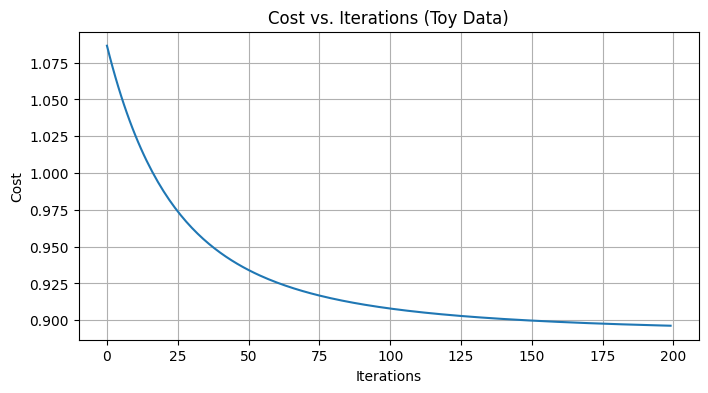


✅ Gradient descent test passed — cost should decrease.


In [7]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to learn W and b for softmax regression.

    Parameters:
        X (np.ndarray): Input features of shape (n, d).
        y (np.ndarray): One-hot encoded true labels of shape (n, c).
        W (np.ndarray): Initial weight matrix of shape (d, c).
        b (np.ndarray): Initial bias vector of shape (c,).
        alpha (float): Learning rate.
        n_iter (int): Number of iterations.
        show_cost (bool): If True, print cost every 100 iterations.

    Returns:
        W (np.ndarray): Learned weight matrix.
        b (np.ndarray): Learned bias vector.
        cost_history (list): List of cost values recorded at each iteration.
    """
    cost_history = []

    for i in range(n_iter):
        dW, db = compute_gradient_softmax(X, y, W, b)
        W = W - alpha * dW
        b = b - alpha * db

        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        if show_cost and i % 100 == 0:
            print(f"Iteration {i:4d} | Cost: {cost:.6f}")

    return W, b, cost_history


# --- Quick test on toy data ---
np.random.seed(42)
X_toy = np.random.randn(20, 3)
y_labels = np.random.randint(0, 3, 20)
y_toy = np.eye(3)[y_labels]
W_init = np.random.randn(3, 3) * 0.01
b_init = np.zeros(3)

W_trained, b_trained, costs = gradient_descent_softmax(
    X_toy, y_toy, W_init, b_init, alpha=0.1, n_iter=200, show_cost=True
)

plt.figure(figsize=(8, 4))
plt.plot(costs)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost vs. Iterations (Toy Data)')
plt.grid(True)
plt.show()
print("\n✅ Gradient descent test passed — cost should decrease.")

---
### 7. Data Loading & Visualization

Load the MNIST dataset, normalize pixel values, split into train/test, and visualize one sample per digit.

Loading MNIST dataset (this may take a moment)...
Dataset loaded successfully!
  Training set: 56000 samples
  Test set:     14000 samples
  Features:     784 pixels
  Classes:      10 digits (0-9)


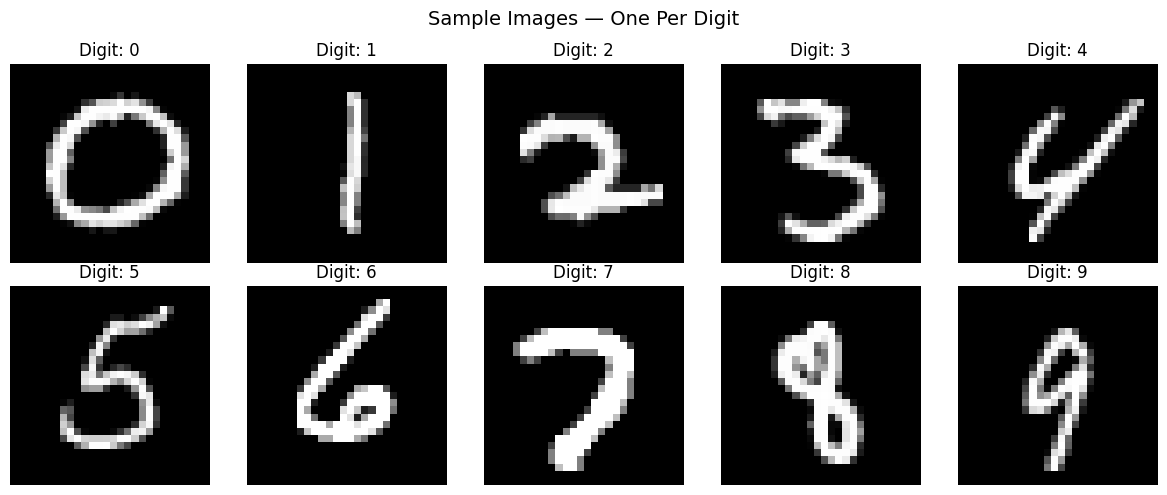

In [8]:
def plot_sample_images(X, y):
    """
    Display one sample image per digit (0–9) in a 2x5 grid.

    Parameters:
        X (np.ndarray): Image data of shape (n, 784).
        y (np.ndarray): Labels of shape (n,).
    """
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for digit in range(10):
        ax = axes[digit // 5, digit % 5]
        idx = np.where(y == digit)[0][0]
        ax.imshow(X[idx].reshape(28, 28), cmap='gray')
        ax.set_title(f'Digit: {digit}')
        ax.axis('off')
    plt.suptitle('Sample Images — One Per Digit', fontsize=14)
    plt.tight_layout()
    plt.show()


def load_and_prepare_mnist(test_size=0.2, random_state=42):
    """
    Load the MNIST dataset using sklearn, normalize, and split.

    Parameters:
        test_size (float): Fraction of data for the test set.
        random_state (int): Random seed for reproducibility.

    Returns:
        X_train, X_test, y_train, y_test: Split and normalized arrays.
    """
    print("Loading MNIST dataset (this may take a moment)...")
    mnist = fetch_openml('mnist_784', version=1, as_frame=False)
    X, y = mnist.data, mnist.target.astype(int)

    # Normalize pixel values to [0, 1]
    X = X / 255.0

    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    print(f"Dataset loaded successfully!")
    print(f"  Training set: {X_train.shape[0]} samples")
    print(f"  Test set:     {X_test.shape[0]} samples")
    print(f"  Features:     {X_train.shape[1]} pixels")
    print(f"  Classes:      {len(np.unique(y_train))} digits (0-9)")

    return X_train, X_test, y_train, y_test


# Load and visualize
X_train, X_test, y_train, y_test = load_and_prepare_mnist()
plot_sample_images(X_train, y_train)

---
### 8. Model Training

One-hot encode labels, initialize weights, and train the model using gradient descent.

One-hot encoded training labels shape: (56000, 10)
One-hot encoded test labels shape:     (14000, 10)

Weight matrix W shape: (784, 10)
Bias vector b shape:   (10,)

--- Training Softmax Regression ---
Iteration    0 | Cost: 2.219401
Iteration  100 | Cost: 0.604916
Iteration  200 | Cost: 0.486701
Iteration  300 | Cost: 0.437907
Iteration  400 | Cost: 0.409728
Iteration  500 | Cost: 0.390807
Iteration  600 | Cost: 0.376960
Iteration  700 | Cost: 0.366246
Iteration  800 | Cost: 0.357626
Iteration  900 | Cost: 0.350488


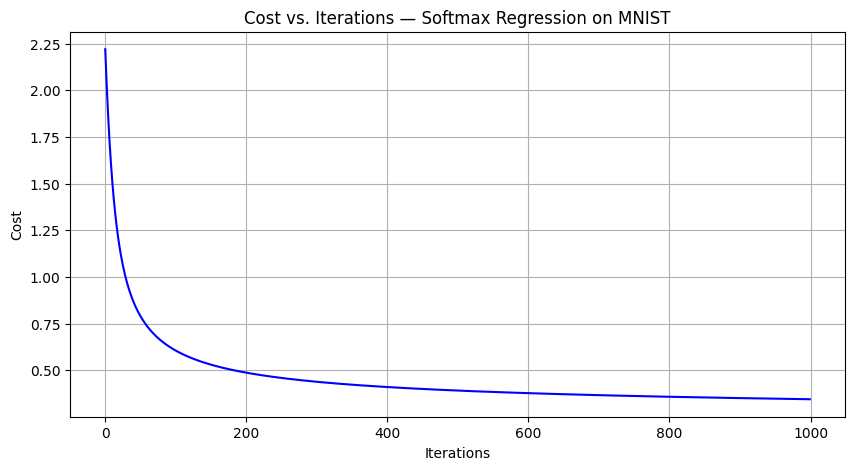


Final cost: 0.344503


In [9]:
# One-hot encode the labels
encoder = OneHotEncoder(sparse_output=False, categories='auto')
y_train_oh = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_oh = encoder.transform(y_test.reshape(-1, 1))

print(f"One-hot encoded training labels shape: {y_train_oh.shape}")
print(f"One-hot encoded test labels shape:     {y_test_oh.shape}")

# Initialize weights and biases
np.random.seed(42)
d = X_train.shape[1]  # number of features (784)
c = y_train_oh.shape[1]  # number of classes (10)
W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

print(f"\nWeight matrix W shape: {W.shape}")
print(f"Bias vector b shape:   {b.shape}")

# Train the model
print("\n--- Training Softmax Regression ---")
W_learned, b_learned, cost_history = gradient_descent_softmax(
    X_train, y_train_oh, W, b, alpha=0.1, n_iter=1000, show_cost=True
)

# Plot Cost vs. Iterations
plt.figure(figsize=(10, 5))
plt.plot(cost_history, color='blue')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost vs. Iterations — Softmax Regression on MNIST')
plt.grid(True)
plt.show()

print(f"\nFinal cost: {cost_history[-1]:.6f}")

---
### 9. Model Evaluation

Predict on the test set, compute classification metrics, and visualize the confusion matrix as a heatmap.

Test Accuracy: 90.53%

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1343
           1       0.93      0.97      0.95      1600
           2       0.91      0.87      0.89      1380
           3       0.88      0.88      0.88      1433
           4       0.90      0.91      0.91      1295
           5       0.87      0.84      0.86      1273
           6       0.92      0.94      0.93      1396
           7       0.92      0.92      0.92      1503
           8       0.87      0.85      0.86      1357
           9       0.88      0.88      0.88      1420

    accuracy                           0.91     14000
   macro avg       0.90      0.90      0.90     14000
weighted avg       0.90      0.91      0.90     14000



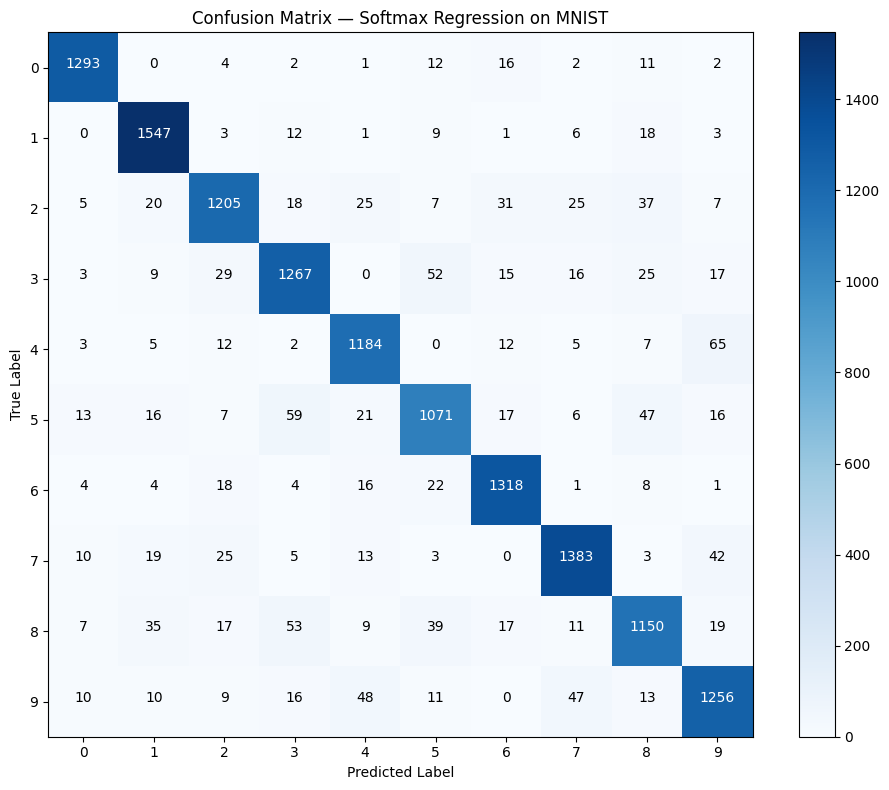

In [10]:
# Predict on the test set
y_pred = predict_softmax(X_test, W_learned, b_learned)

# Accuracy
accuracy = np.mean(y_pred == y_test) * 100
print(f"Test Accuracy: {accuracy:.2f}%\n")

# Classification Report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize Confusion Matrix as a Heatmap
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix — Softmax Regression on MNIST')
plt.colorbar()
tick_marks = np.arange(10)
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)

# Annotate each cell with counts
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

---
### Short Answer — Question 1

**Is extracting pixel values sufficient for effective feature extraction? Why or why not?**

**Answer:**

No, extracting raw pixel values alone is **not sufficient** for truly effective feature extraction, although it works reasonably well for simple datasets like MNIST. The reasons are:

1. **No spatial awareness:** Raw pixel values treat each pixel independently and do not capture the spatial relationships between pixels (e.g., edges, curves, corners). Human digit recognition relies heavily on such structural features.

2. **High dimensionality:** With 784 features per image, the model has to learn from a very high-dimensional space, which can be computationally expensive and prone to overfitting without regularization.

3. **Sensitivity to transformations:** Raw pixel features are not invariant to simple transformations like translation, rotation, or scaling. A digit shifted by even a few pixels looks very different in raw pixel space.

4. **Limited expressiveness:** Softmax regression is a linear classifier — it learns a linear decision boundary. Complex, non-linear patterns in raw pixels are not captured effectively.

More advanced approaches (e.g., Convolutional Neural Networks) automatically learn hierarchical, spatially-aware features (edges → textures → parts → objects), which are far more effective for image classification tasks.

---
## Exercise 2 — Linear Separability & Logistic Regression

Generate linearly separable and non-linearly separable datasets, train Logistic Regression on both, and visualize decision boundaries.

---

In [11]:
def plot_decision_boundary(model, X, y, ax, title):
    """
    Plot the decision boundary of a classifier on a 2D dataset.

    Parameters:
        model: Trained classifier with a predict method.
        X (np.ndarray): Feature matrix of shape (n, 2).
        y (np.ndarray): Labels of shape (n,).
        ax: Matplotlib axis to plot on.
        title (str): Title for the subplot.
    """
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='black', s=30)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

Logistic Regression Accuracy (Linear — Train): 85.0%
Logistic Regression Accuracy (Linear — Test):  87.5%
Logistic Regression Accuracy (Circles — Train): 59.4%
Logistic Regression Accuracy (Circles — Test):  55.0%


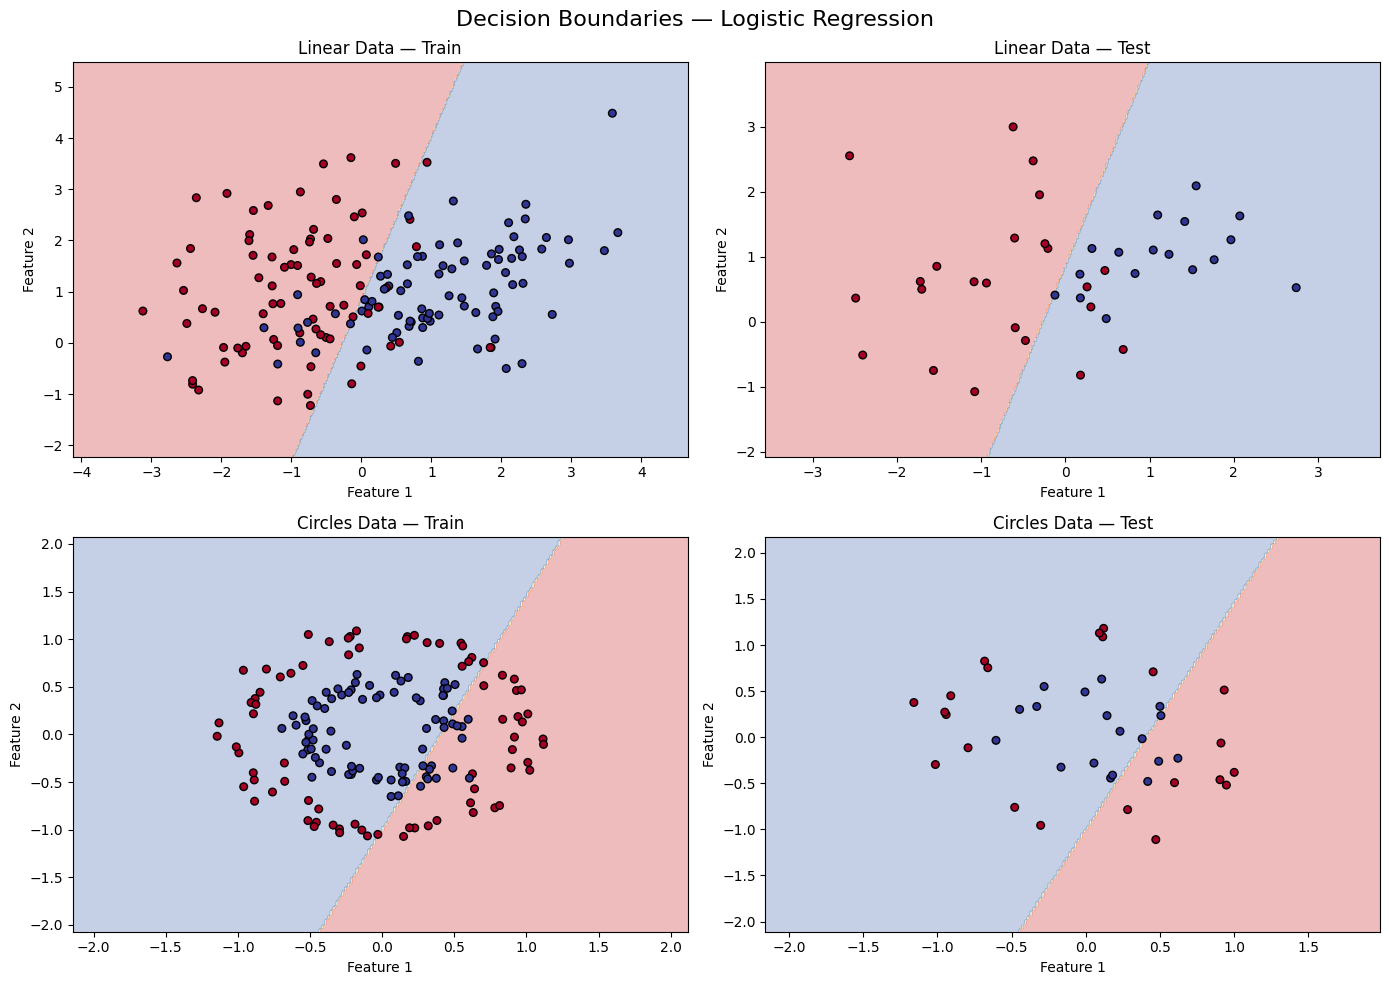


✅ Figure saved as 'decision_boundaries.png'


In [12]:
# --- Generate Datasets ---

# 1. Linearly separable dataset
X_linear, y_linear = make_classification(
    n_samples=200, n_features=2, n_redundant=0,
    n_informative=2, n_clusters_per_class=1, random_state=42
)

# 2. Non-linearly separable dataset (concentric circles)
X_circles, y_circles = make_circles(
    n_samples=200, noise=0.1, factor=0.5, random_state=42
)

# Split both into train/test
X_lin_train, X_lin_test, y_lin_train, y_lin_test = train_test_split(
    X_linear, y_linear, test_size=0.2, random_state=42
)
X_cir_train, X_cir_test, y_cir_train, y_cir_test = train_test_split(
    X_circles, y_circles, test_size=0.2, random_state=42
)

# --- Train Logistic Regression on both ---
lr_linear = LogisticRegression(random_state=42)
lr_linear.fit(X_lin_train, y_lin_train)

lr_circles = LogisticRegression(random_state=42)
lr_circles.fit(X_cir_train, y_cir_train)

print(f"Logistic Regression Accuracy (Linear — Train): {lr_linear.score(X_lin_train, y_lin_train)*100:.1f}%")
print(f"Logistic Regression Accuracy (Linear — Test):  {lr_linear.score(X_lin_test, y_lin_test)*100:.1f}%")
print(f"Logistic Regression Accuracy (Circles — Train): {lr_circles.score(X_cir_train, y_cir_train)*100:.1f}%")
print(f"Logistic Regression Accuracy (Circles — Test):  {lr_circles.score(X_cir_test, y_cir_test)*100:.1f}%")

# --- Plot 4 Decision Boundary Subplots ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_decision_boundary(lr_linear, X_lin_train, y_lin_train,
                       axes[0, 0], 'Linear Data — Train')
plot_decision_boundary(lr_linear, X_lin_test, y_lin_test,
                       axes[0, 1], 'Linear Data — Test')
plot_decision_boundary(lr_circles, X_cir_train, y_cir_train,
                       axes[1, 0], 'Circles Data — Train')
plot_decision_boundary(lr_circles, X_cir_test, y_cir_test,
                       axes[1, 1], 'Circles Data — Test')

plt.suptitle('Decision Boundaries — Logistic Regression', fontsize=16)
plt.tight_layout()
plt.savefig('decision_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Figure saved as 'decision_boundaries.png'")

---
### Short Answer — Question 2

**Provide an interpretation of the output — what do the decision boundaries reveal about logistic regression's behavior on linearly vs. non-linearly separable data?**

**Answer:**

The decision boundary plots reveal the fundamental limitation of logistic regression as a **linear classifier**:

1. **Linearly separable data:** Logistic regression performs very well. It finds a clean linear decision boundary (a straight line in 2D) that effectively separates the two classes in both the training and test sets, achieving high accuracy.

2. **Non-linearly separable data (circles):** Logistic regression performs poorly. The concentric circle dataset requires a **circular (non-linear) boundary** to separate the inner and outer classes. Since logistic regression can only learn a straight line, it cuts through both classes and achieves accuracy close to 50% (near random guessing).

**Key takeaway:** Logistic regression is only effective when the data is linearly separable. For non-linear decision boundaries, more powerful models are needed — such as kernel SVMs, decision trees, or neural networks — that can capture complex, non-linear relationships in the data.

---
### Short Answer — Question 3

**Describe any challenges you faced while implementing the code.**

**Answer:**

Several challenges were encountered during the implementation:

1. **Numerical stability in softmax:** Without subtracting the row-wise maximum before exponentiating, `np.exp()` can produce `inf` values for large logits, leading to `NaN` outputs. Adding the stabilization step (`z - max(z)`) was critical.

2. **Log of zero in cross-entropy:** When a predicted probability is exactly 0, `log(0)` produces `-inf`. Using `np.clip()` to bound predictions away from 0 and 1 was necessary to avoid this.

3. **Shape mismatches:** Ensuring correct matrix dimensions throughout the pipeline (especially during gradient computation with transposed matrices) required careful attention to shapes at each step.

4. **Learning rate tuning:** A learning rate too high caused the cost to diverge (NaN values), while a rate too low resulted in extremely slow convergence. The value `alpha=0.1` provided a good balance for the MNIST dataset.

5. **One-hot encoding:** Properly converting integer labels to one-hot vectors and ensuring the encoder was consistent between training and test sets required careful use of `sklearn.preprocessing.OneHotEncoder`.